<a href="https://colab.research.google.com/github/gabguagon/tif-visualizacion-narrativa/blob/main/Unidad_I_Grupo5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PI — Unidad I: "Del dato a la decisión"

### Tablero de control y análisis exploratorio — `operacion_organizacion.csv`

**Grupo 5**: Gonza Gabriela · Biazutti Luciano

**Módulo**: Visualización y Narrativa de Datos

**Carrera**: Tecnicatura Universitaria en Ciencias de Datos e IA Aplicada — UPATECO

---

## 1. Configuración e importación de librerías

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuración visual general de los gráficos
plt.rcParams.update({
    "font.size": 11,
    "axes.grid": True,
    "grid.color": "#E3E3E3",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})

# Paleta de colores utilizada en el informe
NAVY   = "#1F3864"
BLUE   = "#2E75B6"
LIGHT  = "#9DC3E6"
ORANGE = "#E07B39"
RED    = "#C0392B"
GREY   = "#8C8C8C"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Carga de datos


In [18]:
#Esta función carga uno o varios archivos CSV del dataset desde el repositorio de GitHub del grupo
def cargar_dataset(archivos: list) -> pd.DataFrame:
    """Descarga y concatena archivos CSV desde el repositorio GitHub del proyecto."""
    GITHUB_USER = 'gabguagon'
    GITHUB_REPO = 'tif-visualizacion-narrativa'
    GITHUB_BRANCH = 'main'
    DATASET_DIR = 'dataset'
    BASE_URL = (
        f'https://raw.githubusercontent.com/'
        f'{GITHUB_USER}/{GITHUB_REPO}/{GITHUB_BRANCH}/{DATASET_DIR}'
    )

    dfs = [pd.read_csv(f'{BASE_URL}/{archivo}', parse_dates=['Fecha']) for archivo in archivos]
    return pd.concat(dfs, ignore_index=True)

print('Carga del dataset...')
df = cargar_dataset(['operacion_organizacion.csv'])

# Se guarda la cantidad de columnas originales para usarla más adelante
N_COLUMNAS_ORIGINALES = df.shape[1]

print(f'\nDimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()


Carga del dataset...

Dimensiones: 506 filas × 12 columnas


,ID,Fecha,Unidad,Region,Actividad,Horas,Recursos,Incidentes,Tiempo,Calidad,Costo,Resultado
0,499,2023-05-23,C,Norte,159.0,193.9,12,1,15.47,92.6,29890.0,225.1
1,95,2023-06-11,D,Sur,98.0,188.2,27,2,23.91,93.9,20584.0,140.2
2,151,2024-05-17,E,Norte,151.0,148.9,11,2,14.91,NaN,26795.0,232.5
3,222,2023-08-13,D,Centro,93.0,161.2,13,3,15.26,95.6,21543.0,128.5
4,424,2023-02-18,B,Norte,120.0,149.4,17,0,13.84,94.7,23026.0,192.0


## 3. Exploración inicial del dataset

### 3.1 Estructura general y tipos de datos

In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          506 non-null    int64         
 1   Fecha       506 non-null    datetime64[ns]
 2   Unidad      506 non-null    object        
 3   Region      506 non-null    object        
 4   Actividad   506 non-null    float64       
 5   Horas       498 non-null    float64       
 6   Recursos    506 non-null    int64         
 7   Incidentes  506 non-null    int64         
 8   Tiempo      498 non-null    float64       
 9   Calidad     498 non-null    float64       
 10  Costo       506 non-null    float64       
 11  Resultado   506 non-null    float64       
dtypes: datetime64[ns](1), float64(6), int64(3), object(2)
memory usage: 47.6+ KB


In [20]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,506.0,NaN,NaN,NaN,250.229249,1.0,127.25,249.5,374.75,500.0,144.106008
Fecha,506,NaN,NaN,NaN,2024-04-03 23:05:55.731225088,2023-01-02 00:00:00,2023-08-18 06:00:00,2024-04-12 12:00:00,2024-11-15 18:00:00,2025-06-25 00:00:00,NaN
Unidad,506,5,C,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,506,3,Sur,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Actividad,506.0,NaN,NaN,NaN,118.675889,55.0,100.715,118.0,137.0,198.0,26.536241
Horas,498.0,NaN,NaN,NaN,164.553213,98.0,151.525,164.75,177.4,218.5,19.565312
Recursos,506.0,NaN,NaN,NaN,20.875494,8.0,15.0,20.0,28.0,34.0,7.672138
Incidentes,506.0,NaN,NaN,NaN,2.367589,0.0,1.0,2.0,3.0,9.0,1.730122
Tiempo,498.0,NaN,NaN,NaN,18.411044,9.68,15.9925,18.2,20.63,30.51,3.400278
Calidad,498.0,NaN,NaN,NaN,89.94739,71.4,87.3,90.3,93.4,100.0,4.791341


### 3.2 Período temporal cubierto

In [21]:
print("Fecha mínima:", df['Fecha'].min().date())
print("Fecha máxima:", df['Fecha'].max().date())
print("Días cubiertos:", (df['Fecha'].max() - df['Fecha'].min()).days)

print("\nRegistros por año:")
print(df['Fecha'].dt.year.value_counts().sort_index())

print("\nRegistros por mes:")
print(df['Fecha'].dt.to_period('M').value_counts().sort_index())


Fecha mínima: 2023-01-02
Fecha máxima: 2025-06-25
Días cubiertos: 905

Registros por año:
Fecha
2023    194
2024    209
2025    103
Name: count, dtype: int64

Registros por mes:
Fecha
2023-01    18
2023-02    18
2023-03     7
2023-04    20
2023-05    19
2023-06    17
2023-07    17
2023-08    21
2023-09    15
2023-10    16
2023-11    10
2023-12    16
2024-01    21
2024-02    20
2024-03    10
2024-04    23
2024-05    24
2024-06     8
2024-07    22
2024-08     8
2024-09    15
2024-10    21
2024-11    22
2024-12    15
2025-01    13
2025-02    18
2025-03    23
2025-04    14
2025-05    23
2025-06    12
Freq: M, Name: count, dtype: int64


### 3.3 Variables categóricas

In [22]:
print("Unidades operativas:")
print(df['Unidad'].value_counts())

print("\nRegiones:")
print(df['Region'].value_counts())


Unidades operativas:
Unidad
C    118
D    102
B    102
E     96
A     88
Name: count, dtype: int64

Regiones:
Region
Sur       185
Norte     170
Centro    151
Name: count, dtype: int64


### ¿Qué representa cada variable del dataset?

El dataset contiene 506 registros (filas) y 12 columnas. Cada fila parece representar una operación ejecutado por una unidad operativa de la organización en una fecha y región determinadas.

| Variable | Tipo de dato | Interpretación propuesta |
| :--- | :--- | :--- |
| **ID** | Numérico (entero) | Identificador del registro/operación. Rango 1-500 con 500 valores únicos sobre 506 filas, lo que evidencia registros duplicados. |
| **Fecha** | Fecha (AAAA-MM-DD) | Fecha en que se realizó u observó la operación. Cubre desde el 02/01/2023 hasta el 25/06/2025. |
| **Unidad** | Categórico nominal (A-E) | Unidad operativa, equipo o sucursal responsable de la operación. 5 categorías con volúmenes similares (88 a 118 casos). |
| **Region** | Categórico nominal (Norte/Sur/Centro) | Región geográfica donde se ejecutó la operación. 3 categorías. |
| **Actividad** | Numérico (continuo) | Volumen o nivel de actividad de la operación (posiblemente unidades producidas, tareas ejecutadas o carga de trabajo). Es la variable con mayor correlación con el Resultado (r=0,97). |
| **Horas** | Numérico (continuo) | Horas trabajadas o insumidas en la operación. Rango aproximado 98 a 218 horas. |
| **Recursos** | Numérico (entero) | Cantidad de recursos (personas, equipos o materiales) asignados a la operación. Rango 8 a 34. |
| **Incidentes** | Numérico (entero) | Cantidad de incidentes, desvíos o eventos no deseados registrados durante la operación. Rango 0 a 9. |
| **Tiempo** | Numérico (continuo) | Tiempo de ciclo o duración del proceso, en una unidad no especificada (posiblemente días u horas). Rango 9,68 a 30,51. |
| **Calidad** | Numérico (continuo, %) | Indicador de calidad del proceso o del resultado, expresado en una escala de 0 a 100. Rango observado 71,4 a 100. |
| **Costo** | Numérico (continuo, moneda) | Costo monetario asociado a la operación. Rango aproximado $14.951 a $38.103. |
| **Resultado** | Numérico (continuo) | Variable de desempeño u output final de la operación. Fuertemente correlacionada con Actividad (r=0,97) y con Costo (r=0,63). |

### ¿Qué tipo de dato contiene cada columna?

Desde el punto de vista técnico, las columnas se agrupan en estos tipos de datos:

*   **Identificador:** ID (entero).
*   **Temporal:** Fecha (fecha calendario, formato AAAA-MM-DD).
*   **Categórico nominal:** Unidad (5 categorías: A, B, C, D, E) y Region (3 categorías: Norte, Sur, Centro).
*   **Numérico discreto:** Recursos e Incidentes (valores enteros, propios de conteos).
*   **Numérico continuo:** Actividad, Horas, Tiempo, Calidad, Costo y Resultado.

### ¿Qué período temporal abarca la información?
El dataset abarca 905 días corridos, desde el 2 de enero de 2023 hasta el 25 de junio de 2025 (dos años y medio aproximadamente). La distribución de registros por año es la siguiente: 194 registros en 2023, 209 registros en 2024 y 103 registros en 2025 (el año 2025 está incompleto, ya que los datos llegan solo hasta junio).

La cobertura mensual no es perfectamente uniforme: se observan meses con más registros (por ejemplo, abril y mayo de 2024, con 23-24 casos) y meses con muy pocos registros (marzo de 2023 con 7 casos, o junio y agosto de 2024 con 8 casos cada uno). Esta irregularidad debe tenerse en cuenta al comparar promedios mensuales, ya que meses con pocos registros son más sensibles a valores extremos.

## 4. Calidad de datos

### 4.1 Valores faltantes

In [23]:
nulos = df.isnull().sum()
print(nulos[nulos > 0])

pct_con_nulo = df.isnull().any(axis=1).sum() / len(df) * 100
print(f"\nRegistros con al menos un valor faltante: {df.isnull().any(axis=1).sum()} ({pct_con_nulo:.2f}%)")


Horas      8
Tiempo     8
Calidad    8
dtype: int64

Registros con al menos un valor faltante: 22 (4.35%)


### 4.2 Registros duplicados

In [24]:
duplicados = df[df.duplicated(keep=False)].sort_values('ID')
print(f"Filas involucradas en duplicados exactos: {len(duplicados)}")
print(f"Pares duplicados: {df.duplicated().sum()}")
duplicados


Filas involucradas en duplicados exactos: 12
Pares duplicados: 6


,ID,Fecha,Unidad,Region,Actividad,Horas,Recursos,Incidentes,Tiempo,Calidad,Costo,Resultado
61,132,2023-05-19,C,Sur,119.0,194.1,30,2,12.79,91.7,25145.0,169.2
489,132,2023-05-19,C,Sur,119.0,194.1,30,2,12.79,91.7,25145.0,169.2
393,152,2024-02-11,E,Sur,137.0,122.4,25,3,15.41,87.6,22077.0,202.1
146,152,2024-02-11,E,Sur,137.0,122.4,25,3,15.41,87.6,22077.0,202.1
296,155,2025-03-15,B,Sur,140.0,137.9,20,0,19.55,90.7,23422.0,209.5
399,155,2025-03-15,B,Sur,140.0,137.9,20,0,19.55,90.7,23422.0,209.5
481,191,2023-08-19,B,Centro,118.0,139.8,27,0,13.38,85.2,20681.0,179.9
84,191,2023-08-19,B,Centro,118.0,139.8,27,0,13.38,85.2,20681.0,179.9
94,311,2023-12-12,D,Sur,129.0,136.0,28,1,14.89,88.6,22257.0,206.1
247,311,2023-12-12,D,Sur,129.0,136.0,28,1,14.89,88.6,22257.0,206.1


### ¿Qué calidad presentan los datos? ¿Existen valores faltantes, duplicados o inconsistencias?

El relevamiento de calidad de datos arrojó los siguientes resultados:

*   **Valores faltantes:** 8 registros sin dato en Horas, 8 sin dato en Tiempo y 8 sin dato en Calidad (no necesariamente las mismas filas). En conjunto, 22 de los 506 registros (4,35%) tienen al menos un valor nulo. Las demás columnas (ID, Fecha, Unidad, Region, Actividad, Recursos, Incidentes, Costo, Resultado) no presentan valores faltantes.
*   **Registros duplicados:** se detectaron 6 pares de filas exactamente duplicadas (mismo ID y mismos valores en las 12 columnas), correspondientes a los ID 132, 152, 155, 191, 311 y 425. Esto equivale a 12 filas involucradas (2,4% del dataset), de las cuales 6 son copias redundantes.
*   **Rangos y outliers puntuales:** no se detectaron valores negativos ni fuera de rango evidente en las variables numéricas (por ejemplo, Calidad se mantiene siempre entre 0 y 100). Los valores extremos observados en Costo, Resultado e Incidentes son consistentes con el resto de la distribución y no sugieren errores de carga.

En conjunto, aproximadamente un 6,7% de los registros presenta algún tipo de particularidad (faltantes o duplicados), por lo que se recomienda documentar y tratar estos casos antes de utilizar el dataset para reportes definitivos o modelos predictivos.

### ¿Qué información consideran que falta para realizar un análisis más completo?
Trabajando exclusivamente con el dataset entregado, el equipo identificó las siguientes ausencias de información que limitan el alcance de las conclusiones:

*	Un diccionario de datos oficial que confirme el significado exacto de cada variable (en particular Actividad, Tiempo y Resultado) y sus unidades de medida.
*	El sector de actividad y el tipo de operación de la organización, necesarios para contextualizar si los valores observados son buenos o malos respecto de un estándar de la industria.
*	Metas u objetivos (targets) definidos por la organización para cada KPI, que permitirían evaluar cumplimiento en lugar de solo comparar unidades entre sí.
*	Costos desagregados (mano de obra, insumos, logística) que permitan entender qué componente explica las diferencias de costo entre unidades y regiones.
*	Datos de clientes o beneficiarios finales de la operación, que permitirían vincular Resultado y Calidad con satisfacción o impacto real.
*	Una definición explícita de qué constituye un “incidente” (severidad, tipo, causa) para poder priorizar acciones correctivas.

## 5. Cálculo de KPIs

### ¿Qué indicadores (KPIs) consideran relevantes?

A partir de las variables disponibles y sus relaciones estadísticas, se propone el siguiente conjunto de KPIs para el tablero de control:

| KPI | Cálculo | Qué mide y por qué se eligió |
| :--- | :--- | :--- |
| **Resultado promedio** | Promedio de Resultado | KPI de desempeño central; es la variable de output final del dataset. |
| **Costo por unidad de Resultado** | Costo / Resultado | Eficiencia económica: cuánto cuesta generar cada unidad de output. Permite comparar unidades y regiones en igualdad de condiciones. |
| **Tasa de incidentes** | Incidentes promedio por registro | Indicador de estabilidad operativa y riesgo; muestra correlación negativa con Resultado (r=-0,30). |
| **Índice de calidad** | Promedio de Calidad (%) | Mide la calidad percibida o medida del proceso; cae marcadamente en el clúster atípico (82,3% vs. 90,9%). |
| **Productividad (Resultado/Horas)** | Resultado / Horas | Aproximación a la eficiencia del uso del tiempo de trabajo. |
| **% de registros con incidencias de calidad de datos** | (Nulos + duplicados + atípicos) / Total | KPI de gobierno de datos: mide qué proporción del dataset requiere depuración antes de un uso definitivo. |

In [25]:
# KPI 1: Costo por unidad de Resultado (eficiencia económica)
df['CostoPorResultado'] = df['Costo'] / df['Resultado']

# KPI 2: Tasa de incidentes (ya está disponible como columna Incidentes)

# KPI 3: Productividad (Resultado por hora trabajada)
df['ProductividadPorHora'] = df['Resultado'] / df['Horas']

# Indicadores globales del dataset
indicadores_globales = pd.Series({
    'Registros totales': len(df),
    'Resultado promedio': df['Resultado'].mean(),
    'Costo promedio': df['Costo'].mean(),
    'Costo total acumulado': df['Costo'].sum(),
    'Incidentes promedio': df['Incidentes'].mean(),
    'Calidad promedio (%)': df['Calidad'].mean(),
    'Costo por unidad de Resultado': df['CostoPorResultado'].mean(),
}).round(2)
indicadores_globales


,0
Registros totales,506.00
Resultado promedio,165.97
Costo promedio,24114.03
Costo total acumulado,12201701.24
Incidentes promedio,2.37
Calidad promedio (%),89.95
Costo por unidad de Resultado,153.40


In [26]:
# KPIs por Unidad operativa
kpis_unidad = df.groupby('Unidad').agg(
    n=('ID', 'count'),
    Resultado_prom=('Resultado', 'mean'),
    Costo_prom=('Costo', 'mean'),
    Incidentes_prom=('Incidentes', 'mean'),
    Calidad_prom=('Calidad', 'mean'),
).round(2)
kpis_unidad['CostoPorResultado'] = (kpis_unidad['Costo_prom'] / kpis_unidad['Resultado_prom']).round(2)
kpis_unidad.sort_values('Resultado_prom', ascending=False)


,n,Resultado_prom,Costo_prom,Incidentes_prom,Calidad_prom,CostoPorResultado
Unidad,,,,,,
B,102,169.96,24117.40,2.21,89.58,141.90
A,88,168.28,24623.61,2.42,89.80,146.33
E,96,165.71,23907.77,2.29,89.85,144.27
C,118,164.67,24239.91,2.41,89.78,147.20
D,102,161.72,23719.55,2.51,90.74,146.67


In [27]:
# KPIs por Región
kpis_region = df.groupby('Region').agg(
    n=('ID', 'count'),
    Resultado_prom=('Resultado', 'mean'),
    Costo_prom=('Costo', 'mean'),
    Incidentes_prom=('Incidentes', 'mean'),
    Calidad_prom=('Calidad', 'mean'),
).round(2)
kpis_region['CostoPorResultado'] = (kpis_region['Costo_prom'] / kpis_region['Resultado_prom']).round(2)
kpis_region.sort_values('Resultado_prom', ascending=False)


,n,Resultado_prom,Costo_prom,Incidentes_prom,Calidad_prom,CostoPorResultado
Region,,,,,,
Norte,170,168.69,24205.73,2.31,90.00,143.49
Centro,151,166.76,24267.63,2.31,90.22,145.52
Sur,185,162.83,23904.40,2.47,89.68,146.81


In [28]:
# Matriz de correlación entre variables numéricas
num_cols = ['Actividad','Horas','Recursos','Incidentes','Tiempo','Calidad','Costo','Resultado']
correlaciones = df[num_cols].corr()
correlaciones['Resultado'].sort_values(ascending=False)


,Resultado
Resultado,1.000000
Actividad,0.973204
Costo,0.632733
Calidad,0.166179
Recursos,0.026748
Horas,-0.042704
Tiempo,-0.222419
Incidentes,-0.300701


## 6. Visualizaciones del tablero de control

### ¿Qué visualizaciones utilizarían y por qué?

*   **Serie de tiempo (línea) del Resultado promedio mensual:** permite detectar tendencias y anomalías temporales, como la caída de septiembre-noviembre 2024.
*   **Gráfico de barras dobles de Resultado y Costo promedio por Unidad:** facilita comparar desempeño y costo entre las cinco unidades operativas de forma simultánea.
*   **Gráfico de barras de Resultado promedio por Región:** identifica diferencias geográficas relevantes para la toma de decisiones territoriales.
*   **Gráfico de barras comparativo (clúster atípico vs. registros regulares):** visualiza el impacto del subconjunto de 58 registros sobre Incidentes, Calidad y Resultado.
*   **Matriz de correlación (heatmap):** resume de un vistazo qué variables están más asociadas al Resultado, orientando qué palancas priorizar.
*   **Histograma de la cantidad de incidentes por registro:** muestra la distribución de riesgo operativo y la proporción de registros sin incidentes.
*   **Diagrama de dispersión (scatter plot) Actividad vs. Resultado:** evidencia visualmente la fuerte relación lineal entre ambas variables y aísla el clúster atípico.

Se priorizaron gráficos de barras y líneas por su facilidad de lectura para un público no técnico (la organización y los stakeholders), reservando el heatmap y el scatter plot como visualizaciones de apoyo para la argumentación técnica del equipo consultor.

### ¿Qué decisiones recomendarían a la organización únicamente con la información disponible?
Recomendamos depurar duplicados antes de cualquier reporte oficial y tomar como referencia de buen desempeño a la Unidad B y a la Región Norte para las próximas revisiones de proceso.


### ¿Qué supuestos debieron realizar durante el análisis?
Dado que no se tiene un diccionario de datos ni el contexto de la organización, se tienen los siguientes supuestos:

*	Se asumió que cada fila representa una operación o evento individual e independiente, y no una medición repetida sobre la misma entidad a lo largo del tiempo.
*	Se asumió que Resultado es la variable de desempeño/output que la organización desea maximizar, y Costo la variable que desea minimizar.
*	Se asumió que Calidad está expresada en una escala porcentual de 0 a 100, dado que su rango observado (71,4-100) es compatible con esa interpretación.
*	Se asumió que los 6 pares de filas idénticas son duplicados de carga y no dos operaciones distintas que coincidieron exactamente en las 12 variables (escenario estadísticamente muy improbable).

## Tablero de control: indicadores y visualizaciones

Todos los valores fueron calculados sobre las 506 filas del dataset, sin excluir ni corregir duplicados, faltantes o registros atípicos.

| Indicador global | Valor |
| :--- | :--- |
| **Registros totales** | 506 |
| **Período cubierto** | 02/01/2023 – 25/06/2025 |
| **Resultado promedio** | 165,97 |
| **Costo promedio** | \$ 24.114,03 |
| **Costo total acumulado** | \$ 12.201.701,24 |
| **Incidentes promedio por registro** | 2,37 |
| **Calidad promedio** | 89,95% |
| **Registros con algún valor faltante** | 22 (4,35%) |
| **Registros duplicados** | 6 pares (12 filas, 2,37%) |
| **Registros del clúster atípico (sep-nov 2024)** | 58 (11,46%) |

### 6.1 Evolución mensual del Resultado promedio

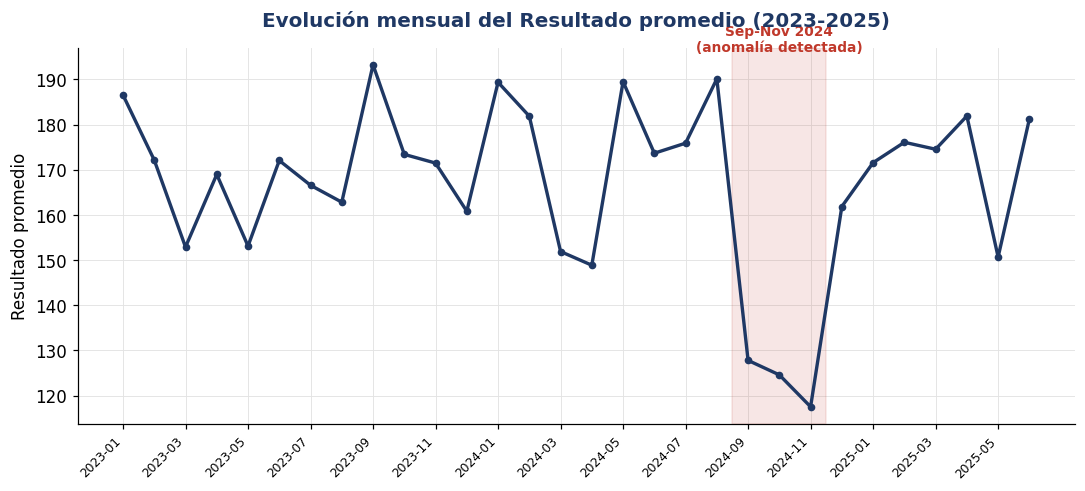

In [29]:
df['Mes'] = df['Fecha'].dt.to_period('M')
mensual = df.groupby('Mes').agg(Resultado=('Resultado', 'mean')).reset_index()
mensual['MesStr'] = mensual['Mes'].astype(str)

fig, ax = plt.subplots(figsize=(10, 4.6), dpi=110)
x = range(len(mensual))
ax.plot(x, mensual['Resultado'], color=NAVY, linewidth=2.2, marker='o', markersize=4, zorder=3)

# Resaltar la ventana de la anomalía detectada (septiembre-noviembre 2024)
meses_atipicos = ['2024-09', '2024-10', '2024-11']
idxs = [i for i, m in enumerate(mensual['MesStr']) if m in meses_atipicos]
if idxs:
    ax.axvspan(min(idxs) - 0.5, max(idxs) + 0.5, color=RED, alpha=0.12, zorder=1)
    ax.text((min(idxs) + max(idxs)) / 2, mensual['Resultado'].max() + 3,
            'Sep-Nov 2024\n(anomalía detectada)', ha='center', fontsize=9, color=RED, fontweight='bold')

ax.set_xticks(list(x)[::2])
ax.set_xticklabels(mensual['MesStr'][::2], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Resultado promedio')
ax.set_title('Evolución mensual del Resultado promedio (2023-2025)', fontsize=13, fontweight='bold', color=NAVY, pad=14)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('01_evolucion_mensual.png', bbox_inches='tight')
plt.show()


Este es el hallazgo más relevante del análisis, fuera de la ventana septiembre-noviembre de 2024, el Resultado promedio mensual oscila de forma relativamente estable entre 150 y 193. Dentro de esa ventana, cae a niveles de entre 117 y 128, para luego volver de inmediato al rango habitual en diciembre de 2024 (Resultado promedio 162) y mantenerse allí durante todo 2025.

### 6.2 Resultado y Costo promedio por Unidad

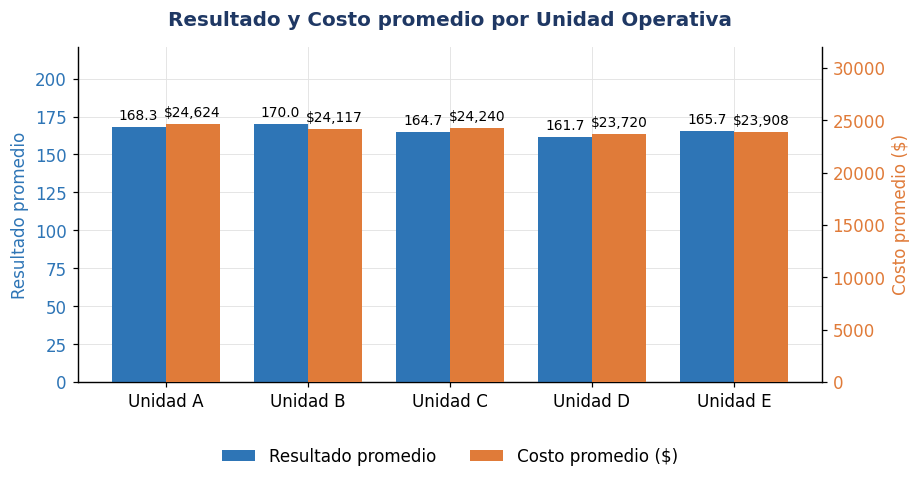

In [30]:
gU = df.groupby('Unidad').agg(Resultado=('Resultado', 'mean'), Costo=('Costo', 'mean')).reindex(['A','B','C','D','E'])

fig, ax1 = plt.subplots(figsize=(8.5, 4.6), dpi=110)
xpos = np.arange(len(gU))
w = 0.38
bars1 = ax1.bar(xpos - w/2, gU['Resultado'], width=w, color=BLUE, label='Resultado promedio', zorder=3)
ax1.bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)
ax1.set_ylabel('Resultado promedio', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax1.set_ylim(0, gU['Resultado'].max() * 1.3)

ax2 = ax1.twinx()
bars2 = ax2.bar(xpos + w/2, gU['Costo'], width=w, color=ORANGE, label='Costo promedio', zorder=3)
ax2.bar_label(bars2, labels=[f'${v:,.0f}' for v in gU['Costo']], padding=3, fontsize=9)
ax2.set_ylabel('Costo promedio ($)', color=ORANGE)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.grid(False)
ax2.set_ylim(0, gU['Costo'].max() * 1.3)

ax1.set_xticks(xpos)
ax1.set_xticklabels([f'Unidad {u}' for u in gU.index])
ax1.set_title('Resultado y Costo promedio por Unidad Operativa', fontsize=13, fontweight='bold', color=NAVY, pad=14)
for spine in ['top']:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

ax1.legend([bars1, bars2], ['Resultado promedio', 'Costo promedio ($)'],
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
plt.tight_layout()
plt.savefig('02_resultado_costo_unidad.png', bbox_inches='tight')
plt.show()

La Unidad B presenta el mejor Resultado promedio (170,0) junto con el menor costo por unidad de Resultado, lo que la posiciona como la más eficiente del conjunto. La Unidad D muestra el Resultado promedio más bajo (161,7) pero también el costo absoluto más bajo, mientras que la Unidad C combina un Resultado intermedio (164,6) con el mayor costo por unidad de Resultado.

### 6.3 Resultado promedio por Región

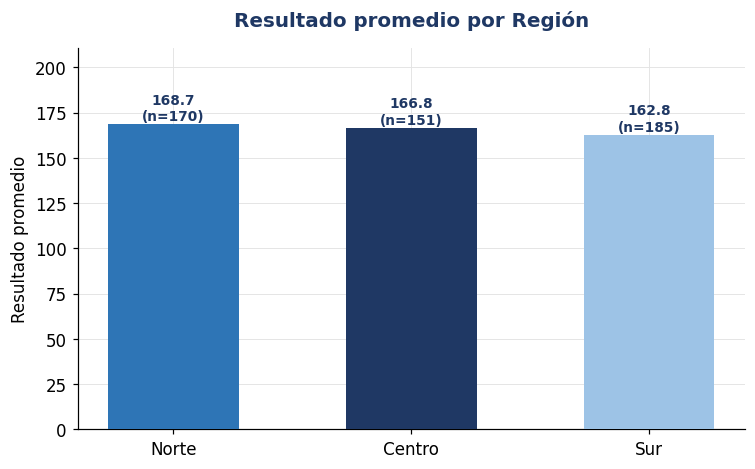

In [31]:
gR = df.groupby('Region').agg(Resultado=('Resultado', 'mean'), n=('ID', 'count')).reindex(['Norte','Centro','Sur'])

fig, ax = plt.subplots(figsize=(7, 4.4), dpi=110)
colors = [BLUE, NAVY, LIGHT]
bars = ax.bar(gR.index, gR['Resultado'], color=colors, zorder=3, width=0.55)
for b, val, n in zip(bars, gR['Resultado'], gR['n']):
    ax.text(b.get_x() + b.get_width()/2, val + 2, f'{val:.1f}\n(n={n})',
            ha='center', fontsize=9, color=NAVY, fontweight='bold')
ax.set_ylabel('Resultado promedio')
ax.set_ylim(0, gR['Resultado'].max() * 1.25)
ax.set_title('Resultado promedio por Región', fontsize=13, fontweight='bold', color=NAVY, pad=14)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('03_resultado_region.png', bbox_inches='tight')
plt.show()


La región Norte lidera en Resultado promedio (168,69) con el mejor costo por unidad de Resultado ($143,49), seguida de Centro (166,76) y por último Sur (162,83), que además concentra la mayor tasa de incidentes promedio (2,47 frente a 2,31 en las otras dos regiones).

### 6.4 Matriz de correlación

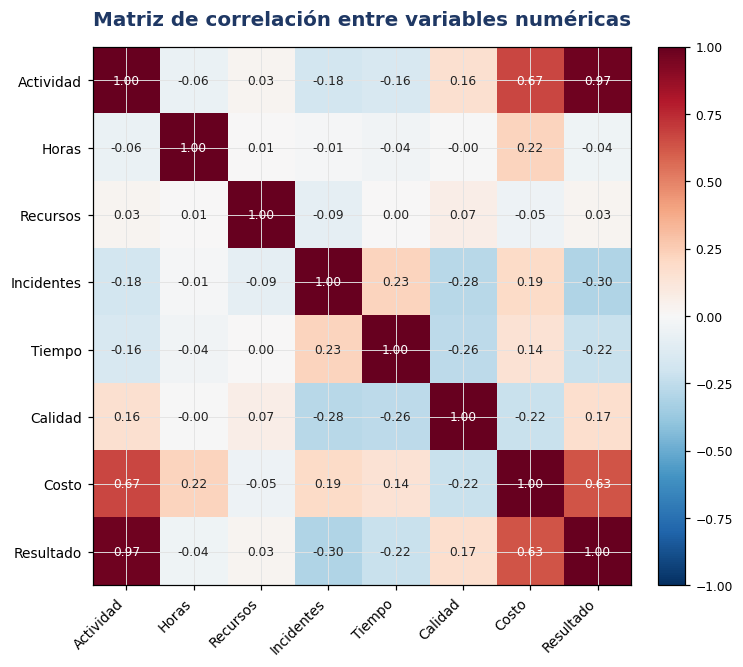

In [33]:
fig, ax = plt.subplots(figsize=(7.2, 6.2), dpi=110)
im = ax.imshow(correlaciones, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = correlaciones.iloc[i, j]
        color = 'white' if abs(val) > 0.55 else '#222222'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=8)
ax.set_title('Matriz de correlación entre variables numéricas', fontsize=13, fontweight='bold', color=NAVY, pad=14)
plt.tight_layout()
plt.savefig('05_correlacion.png', bbox_inches='tight')
plt.show()

Actividad es la variable más correlacionada con Resultado (r=0,97), lo que confirma que Actividad es el principal impulsor del output. Costo también muestra una correlación positiva moderada con Resultado (r=0,63), mientras que Incidentes (r=-0,30) y Tiempo (r=-0,22) presentan correlaciones negativas leves a moderadas: a mayor cantidad de incidentes o mayor tiempo de ciclo, el Resultado tiende a ser menor. Horas y Recursos muestran correlación prácticamente nula con Resultado, lo que sugiere que, dentro de este dataset, agregar horas o recursos por sí solo no garantiza mejor desempeño.

### 6.5 Distribución de incidentes

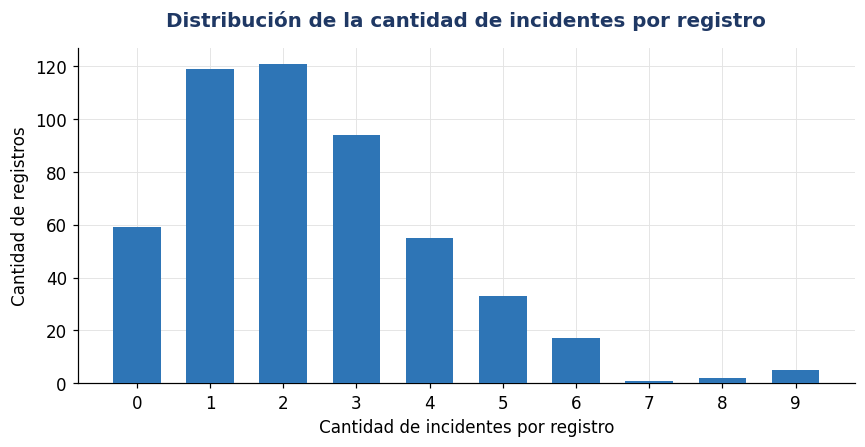

In [34]:
fig, ax = plt.subplots(figsize=(8, 4.2), dpi=110)
counts = df['Incidentes'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=BLUE, width=0.65, zorder=3)
ax.set_xlabel('Cantidad de incidentes por registro')
ax.set_ylabel('Cantidad de registros')
ax.set_title('Distribución de la cantidad de incidentes por registro', fontsize=13, fontweight='bold', color=NAVY, pad=14)
ax.set_xticks(range(0, 10))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('06_distribucion_incidentes.png', bbox_inches='tight')
plt.show()


El 11,7% de los registros (59 casos) no presenta ningún incidente, mientras que el grueso del dataset (el 66%) se concentra entre 1 y 3 incidentes por registro. Un 11,5% de los registros (58 casos) presenta entre 5 y 9 incidentes, un nivel de riesgo considerablemente más alto que la media, y que coincide en buena medida con el clúster atípico descripto en la sección 3.5.

### 6.6 Relación entre Actividad y Resultado

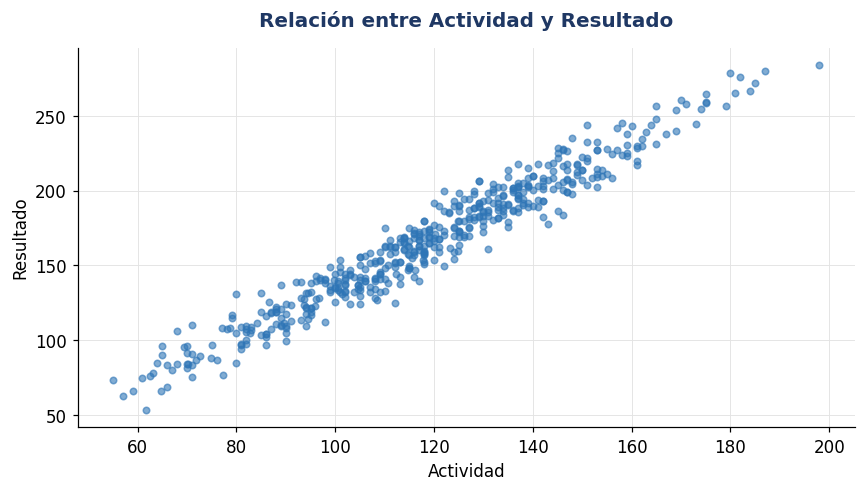

In [36]:
fig, ax = plt.subplots(figsize=(8, 4.6), dpi=110)
ax.scatter(df['Actividad'], df['Resultado'], s=18, color=BLUE, alpha=0.6, zorder=3)
ax.set_xlabel('Actividad')
ax.set_ylabel('Resultado')
ax.set_title('Relación entre Actividad y Resultado', fontsize=13, fontweight='bold', color=NAVY, pad=14)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('06_dispersion_actividad_resultado.png', bbox_inches='tight')
plt.show()

## 7. Tablas resumen

In [37]:
# Tabla 1: Indicadores globales
print("INDICADORES GLOBALES")
print(indicadores_globales)


INDICADORES GLOBALES
Registros totales                     506.00
Resultado promedio                    165.97
Costo promedio                      24114.03
Costo total acumulado            12201701.24
Incidentes promedio                     2.37
Calidad promedio (%)                   89.95
Costo por unidad de Resultado         153.40
dtype: float64


In [38]:
# Tabla 2: KPIs por Unidad
print("KPIs POR UNIDAD")
kpis_unidad


KPIs POR UNIDAD


,n,Resultado_prom,Costo_prom,Incidentes_prom,Calidad_prom,CostoPorResultado
Unidad,,,,,,
A,88,168.28,24623.61,2.42,89.80,146.33
B,102,169.96,24117.40,2.21,89.58,141.90
C,118,164.67,24239.91,2.41,89.78,147.20
D,102,161.72,23719.55,2.51,90.74,146.67
E,96,165.71,23907.77,2.29,89.85,144.27


In [39]:
# Tabla 3: KPIs por Región
print("KPIs POR REGIÓN")
kpis_region


KPIs POR REGIÓN


,n,Resultado_prom,Costo_prom,Incidentes_prom,Calidad_prom,CostoPorResultado
Region,,,,,,
Centro,151,166.76,24267.63,2.31,90.22,145.52
Norte,170,168.69,24205.73,2.31,90.00,143.49
Sur,185,162.83,23904.40,2.47,89.68,146.81
